# Notebook to explore photocentre movements

For paper3. To extract statistics on how the photocentre of an AGB star moves depending
on amount of dust in front of it in images, and for adapting and exploring GAIA data on
AGB stars. To extract photocentre movements of GAIA data.

## Extract Image photocentre

Inspired by the work by Beguin et al 2023 and 2024. Coords of photocentre is an
intensity weighted mean of the xy-positions of all emitting pixels in the image.
Formalised as

  Px = sum_x( sum_y( Image(x,y) * xcoord(x,y))) / sum_x( sum_y( Image(x,y) ))
  Px = sum_x( sum_y( Image(x,y) * ycoord(x,y))) / sum_x( sum_y( Image(x,y) ))

where Image(x,y) are all the pixel fluxes of the image and xcoord and ycoord are all
physical coordinates of the pixels of the images.


-0.07691745881662257 0.1991613097754044
-0.046616641707043986 0.1207038241063057


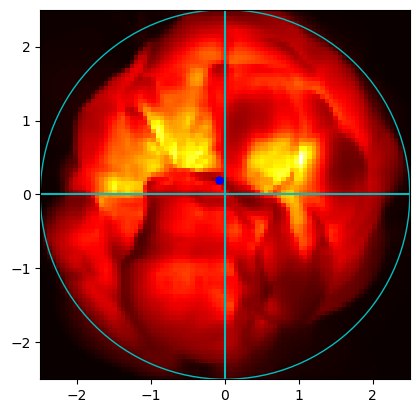

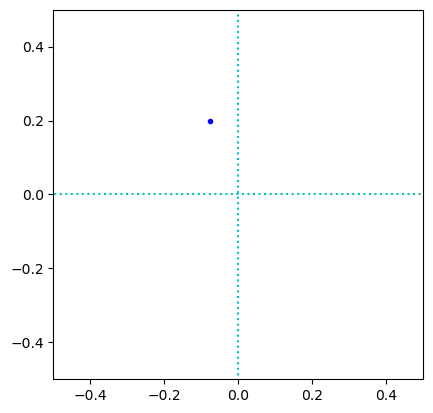

In [ ]:
# Test with only one snapshot and one image
import analyze_r3d_functions as a3d
import matplotlib.pyplot as plt
import numpy as np

modelname = 'st28gm06n052_nodust'
snapshot = '250'
angle = 'i000_phi000'
wavelength = '02'
beamradius = 2.5
# Gaia beam size at 2um is between 1.01 and 0.34 asec
# at 100pc : 101 to 34 au. So the 30x30 image size is not bad to use

image2d,image2dlog,totalflux,axisplot = a3d.load_images(
    path=f'../r3dresults/{modelname}/{snapshot}/',
    image=f'image_{angle}_{wavelength}um.out',
    distance=1
)
# Testplot just to see
plt.figure(1)
plt.imshow(
    image2d, origin='lower', extent=axisplot, cmap=plt.get_cmap('hot')
)
# Compute photocentreposition
# Uses Eqs 6 and 7 from Beguin+2024
(Nx,Ny) = np.shape(image2d)
xrange = np.linspace(axisplot[0],axisplot[1],Nx)
yrange = np.linspace(axisplot[2],axisplot[3],Ny)


nominatorX = 0
nominatorY = 0

demoninator = 0

for nx in range(Nx):
    for ny in range(Ny):
        if np.sqrt(xrange[nx]**2 + yrange[ny]**2) < beamradius:
            
            # Xcoord-sums
            nominatorX += image2d[ny,nx] * xrange[nx]

            # Ycoord-sums
            nominatorY += image2d[ny,nx] * yrange[ny]

            # Common demoninator
            demoninator += image2d[ny,nx]


Px = nominatorX/demoninator
Py = nominatorY/demoninator

print(Px,Py)
print(Px/1.65,Py/1.65)

# Plot to check
plt.plot([-4,4],[0,0],'c-')
plt.plot([0,0],[-4,4],'c-')
plotbeam = plt.Circle((0,0),beamradius,color='c',fill=False)
plt.plot(Px,Py,'b.',markersize=10)
plt.ylim(-2.5,2.5);
plt.xlim(-2.5,2.5);
plt.gca().add_patch(plotbeam)

# Plot only coordinate, close-up
fig,ax = plt.figure(2), plt.axes()
ax.plot(Px,Py,'b.')
ax.plot([-4,4],[0,0],'c:')
ax.plot([0,0],[-4,4],'c:')
ax.set_ylim(-0.5,0.5);
ax.set_xlim(-0.5,0.5);
ax.set_aspect('equal', 'box')

In [3]:
# Scan and write new dat-files with photocentre-displacements
#
# TODO
# do this with all 0.62um images when they are done!
# and for all snapshots
# for all three models

import analyze_r3d_functions as a3d
import os
modelnames = [
    #'st28gm06n052_nodust',
    #'st28gm06n052_nospikes',
    #'st28gm06n074_nodust',
    #'st28gm06n074_nospikes',
    #'st28gm06n075_nodust',
    'st28gm06n075_nospikes',
]
for modelname in modelnames:
    print(f'Doing {modelname}')
    a3d.write_photocentre_files(
        model_path=f'../r3dresults_photocentre/{modelname}/',
        wavelength='0.62',
        angles = [
            'i000_phi000',
            'i090_phi000',
            'i090_phi090',
            'i090_phi270',
            'i180_phi000',
            'i270_phi000',
        ],
        beam_size=2.5
    )
os.system('spd-say moo')
# 160min för 3st

Doing st28gm06n074_nospikes
Running: write_photocentre_files
  Writing photocentre file
  At snapshot 100
  At snapshot 200
  At snapshot 300
Done!
Doing st28gm06n075_nodust
Running: write_photocentre_files
  Writing photocentre file
  At snapshot 100
  At snapshot 200
  At snapshot 300
Done!
Doing st28gm06n075_nospikes
Running: write_photocentre_files
  Writing photocentre file


KeyboardInterrupt: 

  Average nodust pcR - st28gm06n052 : 0.08994684595959597 +/- 0.045763663021830873 Rstar
  Average nodust pcR - st28gm06n074 : 0.08977602693602695 +/- 0.046991148831079556 Rstar
  Average nodust pcR - st28gm06n075 : 0.09003313451254628 +/- 0.04508221152069628 Rstar


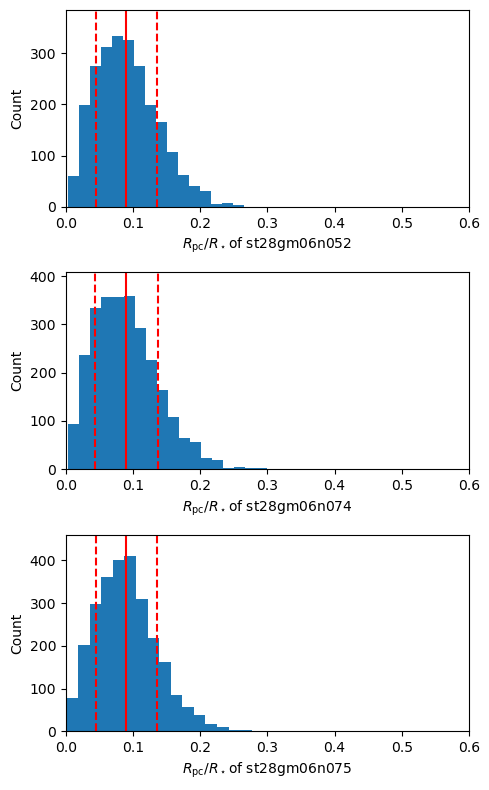

In [ ]:
# Check so that pcR movements are the same for the star for
# all three models
# print and plot variations of pcR
import numpy as np
import analyze_r3d_functions as a3d
import matplotlib.pyplot as plt



# Chose wavelength, prefereably as string to work with filenames
wavelength = '02'
# wavelength = '0.62'
# List model folder names
modelnames_nodust = [
    'st28gm06n052_nodust',
    'st28gm06n074_nodust',
    'st28gm06n075_nodust',
]
Rstar = 1.65
# Initiate figure objects
fig,ax = plt.subplots(
    len(modelnames_nodust),1,
    figsize=(5,8)
)
xlims = [0,0.6]
histbin_size = 0.01*Rstar
# Extract pc-movements without dust for each model
for nmodel,modelname in enumerate(modelnames_nodust):
    #
    pcR_nodust = []
    angles,snapshots,coordinatelist = a3d.load_photocentre_file(
        file_path=f'../r3dresults/{modelname}/photocentre_{wavelength}um.dat'
    )
    # Extract all R(t) for all angles and save in a list
    for nangle,angle in enumerate(angles):
        for nsnapshot in range(len(snapshots)):
            # Save all pc-movements in one list for each model
            pcR_nodust.append(
                coordinatelist[nangle][nsnapshot,2]/Rstar
            )
    # Print overall av-std-numbers
    pcR_average = np.mean(pcR_nodust)
    pcR_std = np.std(pcR_nodust)
    print(
        f'  Average nodust pcR - {modelname.split('_')[0]} : {pcR_average} +/- {pcR_std} Rstar'
    )
    # Plot each models photocentre movements histograms
    # Plot histogram of all nodust
    (Npc, Rrange, patchinfo) = ax[nmodel].hist(
        pcR_nodust,
        int(np.floor(np.max(pcR_nodust)/histbin_size)),
        histtype='stepfilled',
    )
    # Plot averages and stds
    ax[nmodel].plot(
        [pcR_average,pcR_average],
        [0,np.max(Npc)+50],'r'
    )
    ax[nmodel].plot(
        [pcR_average+pcR_std,pcR_average+pcR_std],
        [0,np.max(Npc)+50],'r--'
    )
    ax[nmodel].plot(
        [pcR_average-pcR_std,pcR_average-pcR_std],
        [0,np.max(Npc)+50],'r--'
    )
    # Set axis labels settings
    ax[nmodel].set_ylabel(f'Count')
    ax[nmodel].set_xlabel(r'$R_{\rm pc} / R_\star$'+f'of {modelname.split('_')[0]}')
    ax[nmodel].set_ylim([0,np.max(Npc)+50])
    ax[nmodel].set_xlim(xlims)
# Save figure
fig.tight_layout()


Average for all nodust
  Average pcR : 0.08991686993776778 +/- 0.04596521933877597 Rstar

Average for all with dust
  Average pcR - st28gm06n052 : 0.22849858333333334 +/- 0.2248637429487968 Rstar
  Average pcR - st28gm06n074 : 0.1458795918367347 +/- 0.1512933734557393 Rstar
  Average pcR - st28gm06n075 : 0.09554735111531987 +/- 0.05228356074445337 Rstar


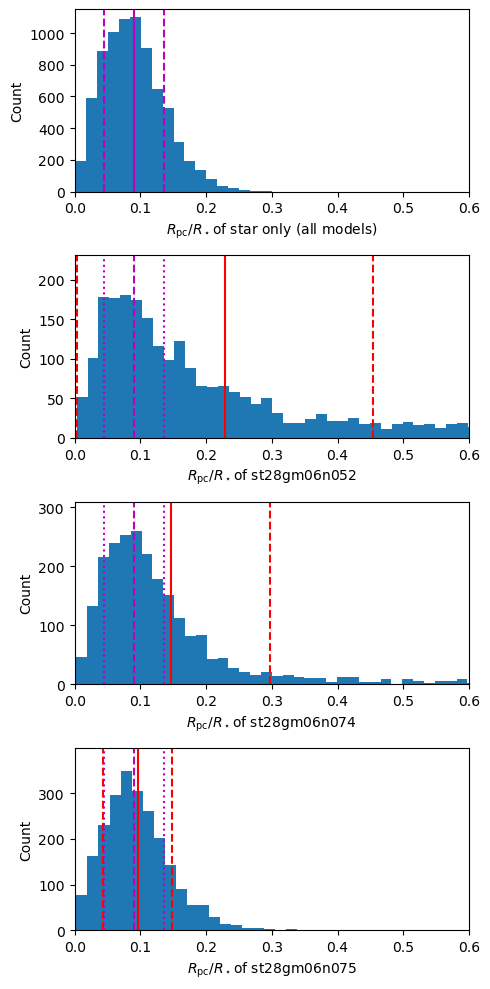

In [8]:
# Load all LOS and 3 nodust-models' photocentre coords
# and plot pcR(time) and statistics of these
# First for each model
# and then all combined, should be the same
import numpy as np
import analyze_r3d_functions as a3d
import matplotlib.pyplot as plt
#
# Chose wavelength, prefereably as string to work with filenames
wavelength = '02'
# wavelength = '0.62'
# List model folder names
modelnames_nodust = [
    'st28gm06n052_nodust',
    'st28gm06n074_nodust',
    'st28gm06n075_nodust',
]
modelnames_dust = [
    'st28gm06n052_nospikes',
    'st28gm06n074_nospikes',
    'st28gm06n075_nospikes',
]
Rstar = 1.65
relaxsnaps = [
    0,29,29
]
# Initiate figure objects
fig,ax = plt.subplots(
    1+len(modelnames_dust),1,
    figsize=(5,10)
)
xlims = [0,0.6]
histbin_size = 0.01*Rstar
# int(np.round(len(snapshots)/10))
# First extract pc-movements without dust and save as one model
pcR_all = []
for modelname in modelnames_nodust:
    #
    angles,snapshots,coordinatelist = a3d.load_photocentre_file(
        file_path=f'../r3dresults/{modelname}/photocentre_{wavelength}um.dat'
    )
    # Extract all R(t) for all angles and save in a list
    for nangle,angle in enumerate(angles):
        for nsnapshot in range(len(snapshots)):
            # Save all models pc-movements in one list
            pcR_all.append(
                coordinatelist[nangle][nsnapshot,2]/Rstar
            )
# Save overall av-std-numbers
pcR_all_average = np.mean(pcR_all)
pcR_all_std = np.std(pcR_all)
print('Average for all nodust')
print(
    f'  Average pcR : {pcR_all_average} +/- {pcR_all_std} Rstar'
)
# Plot histogram of all nodust
(Npc, Rrange, patchinfo) = ax[0].hist(
    pcR_all,
    int(np.floor(np.max(pcR_all)/histbin_size)),
    histtype='stepfilled',
)
# Plot averages and stds
ax[0].plot(
    [pcR_all_average,pcR_all_average],
    [0,np.max(Npc)+50],'m'
)
ax[0].plot(
    [pcR_all_average+pcR_all_std,pcR_all_average+pcR_all_std],
    [0,np.max(Npc)+50],'m--'
)
ax[0].plot(
    [pcR_all_average-pcR_all_std,pcR_all_average-pcR_all_std],
    [0,np.max(Npc)+50],'m--'
)
ax[0].set_ylabel(f'Count')
ax[0].set_xlabel(r'$R_{\rm pc} / R_\star$'+'of star only (all models)')
ax[0].set_ylim([0,np.max(Npc)+50])
ax[0].set_xlim(xlims)
# Extract and plot PC-movements of each model, with dust
print('\nAverage for all with dust')
for nmodel,modelname in enumerate(modelnames_dust):
    # Extract relaxation snapshot
    relaxsnap = relaxsnaps[nmodel]
    # List with photocentre movements for each model
    pcR_time = []
    angles,snapshots,coordinatelist = a3d.load_photocentre_file(
        file_path=f'../r3dresults/{modelname}/photocentre_{wavelength}um.dat'
    )
    # Extract all R(t) for all angles and save in a list
    for nangle,angle in enumerate(angles):
        for nsnapshot in range(relaxsnap,len(snapshots)-relaxsnap):
            pcR_time.append(
                coordinatelist[nangle][nsnapshot+relaxsnap,2]/Rstar
            )
    # Print overall av-std-numbers
    pcR_average = np.mean(pcR_time)
    pcR_std = np.std(pcR_time)
    print(
        f'  Average pcR - {modelname.split('_')[0]} : {pcR_average} +/- {pcR_std} Rstar'
    )
    # Plot each models photocentre movements histograms
    # Plot histogram of all nodust
    (Npc, Rrange, patchinfo) = ax[1+nmodel].hist(
        pcR_time,
        int(np.floor(np.max(pcR_time)/histbin_size)),
        histtype='stepfilled',
    )
    # Plot averages and stds
    ax[1+nmodel].plot(
        [pcR_average,pcR_average],
        [0,np.max(Npc)+50],'r'
    )
    ax[1+nmodel].plot(
        [pcR_average+pcR_std,pcR_average+pcR_std],
        [0,np.max(Npc)+50],'r--'
    )
    ax[1+nmodel].plot(
        [pcR_average-pcR_std,pcR_average-pcR_std],
        [0,np.max(Npc)+50],'r--'
    )
    # Also plot star's average and std
    ax[1+nmodel].plot(
        [pcR_all_average,pcR_all_average],
        [0,np.max(Npc)+50],'m--'
    )
    ax[1+nmodel].plot(
        [pcR_all_average+pcR_all_std,pcR_all_average+pcR_all_std],
        [0,np.max(Npc)+50],'m:'
    )
    ax[1+nmodel].plot(
        [pcR_all_average-pcR_all_std,pcR_all_average-pcR_all_std],
        [0,np.max(Npc)+50],'m:'
    )
    # Set axis labels settings
    ax[1+nmodel].set_ylabel(f'Count')
    ax[1+nmodel].set_xlabel(r'$R_{\rm pc} / R_\star$'+f'of {modelname.split('_')[0]}')
    ax[1+nmodel].set_ylim([0,np.max(Npc)+50])
    ax[1+nmodel].set_xlim(xlims)

# Save figure
fig.tight_layout()
fig.savefig(f'../r3dplots/photocentre/all_{wavelength}um_photocentre_histogram.pdf')



st28gm06n052_nodust   #   average X , Y  (R)   # unit = Rstar
  i000_phi000: -0.02156 , 0.00800  (0.09376)
  i090_phi000: -0.00464 , 0.00237  (0.08472)
  i090_phi090: -0.01575 , 0.03291  (0.08762)
  i090_phi270: 0.00670 , -0.03356  (0.08783)
  i180_phi000: 0.03212 , -0.01066  (0.09419)
  i270_phi000: -0.00654 , 0.00330  (0.09157)

st28gm06n074_nodust   #   average X , Y  (R)   # unit = Rstar
  i000_phi000: -0.04070 , -0.01423  (0.08919)
  i090_phi000: 0.00874 , -0.01724  (0.08127)
  i090_phi090: 0.01011 , 0.03927  (0.09050)
  i090_phi270: 0.00545 , -0.03845  (0.09397)
  i180_phi000: 0.04259 , -0.01553  (0.09268)
  i270_phi000: -0.01210 , -0.01084  (0.09104)

st28gm06n075_nodust   #   average X , Y  (R)   # unit = Rstar
  i000_phi000: 0.00502 , 0.02122  (0.08583)
  i090_phi000: 0.01437 , 0.01979  (0.09326)
  i090_phi090: 0.00832 , -0.00479  (0.09645)
  i090_phi270: 0.01037 , 0.00456  (0.09063)
  i180_phi000: -0.00075 , 0.02035  (0.08692)
  i270_phi000: -0.00765 , 0.02279  (0.08709)

st2

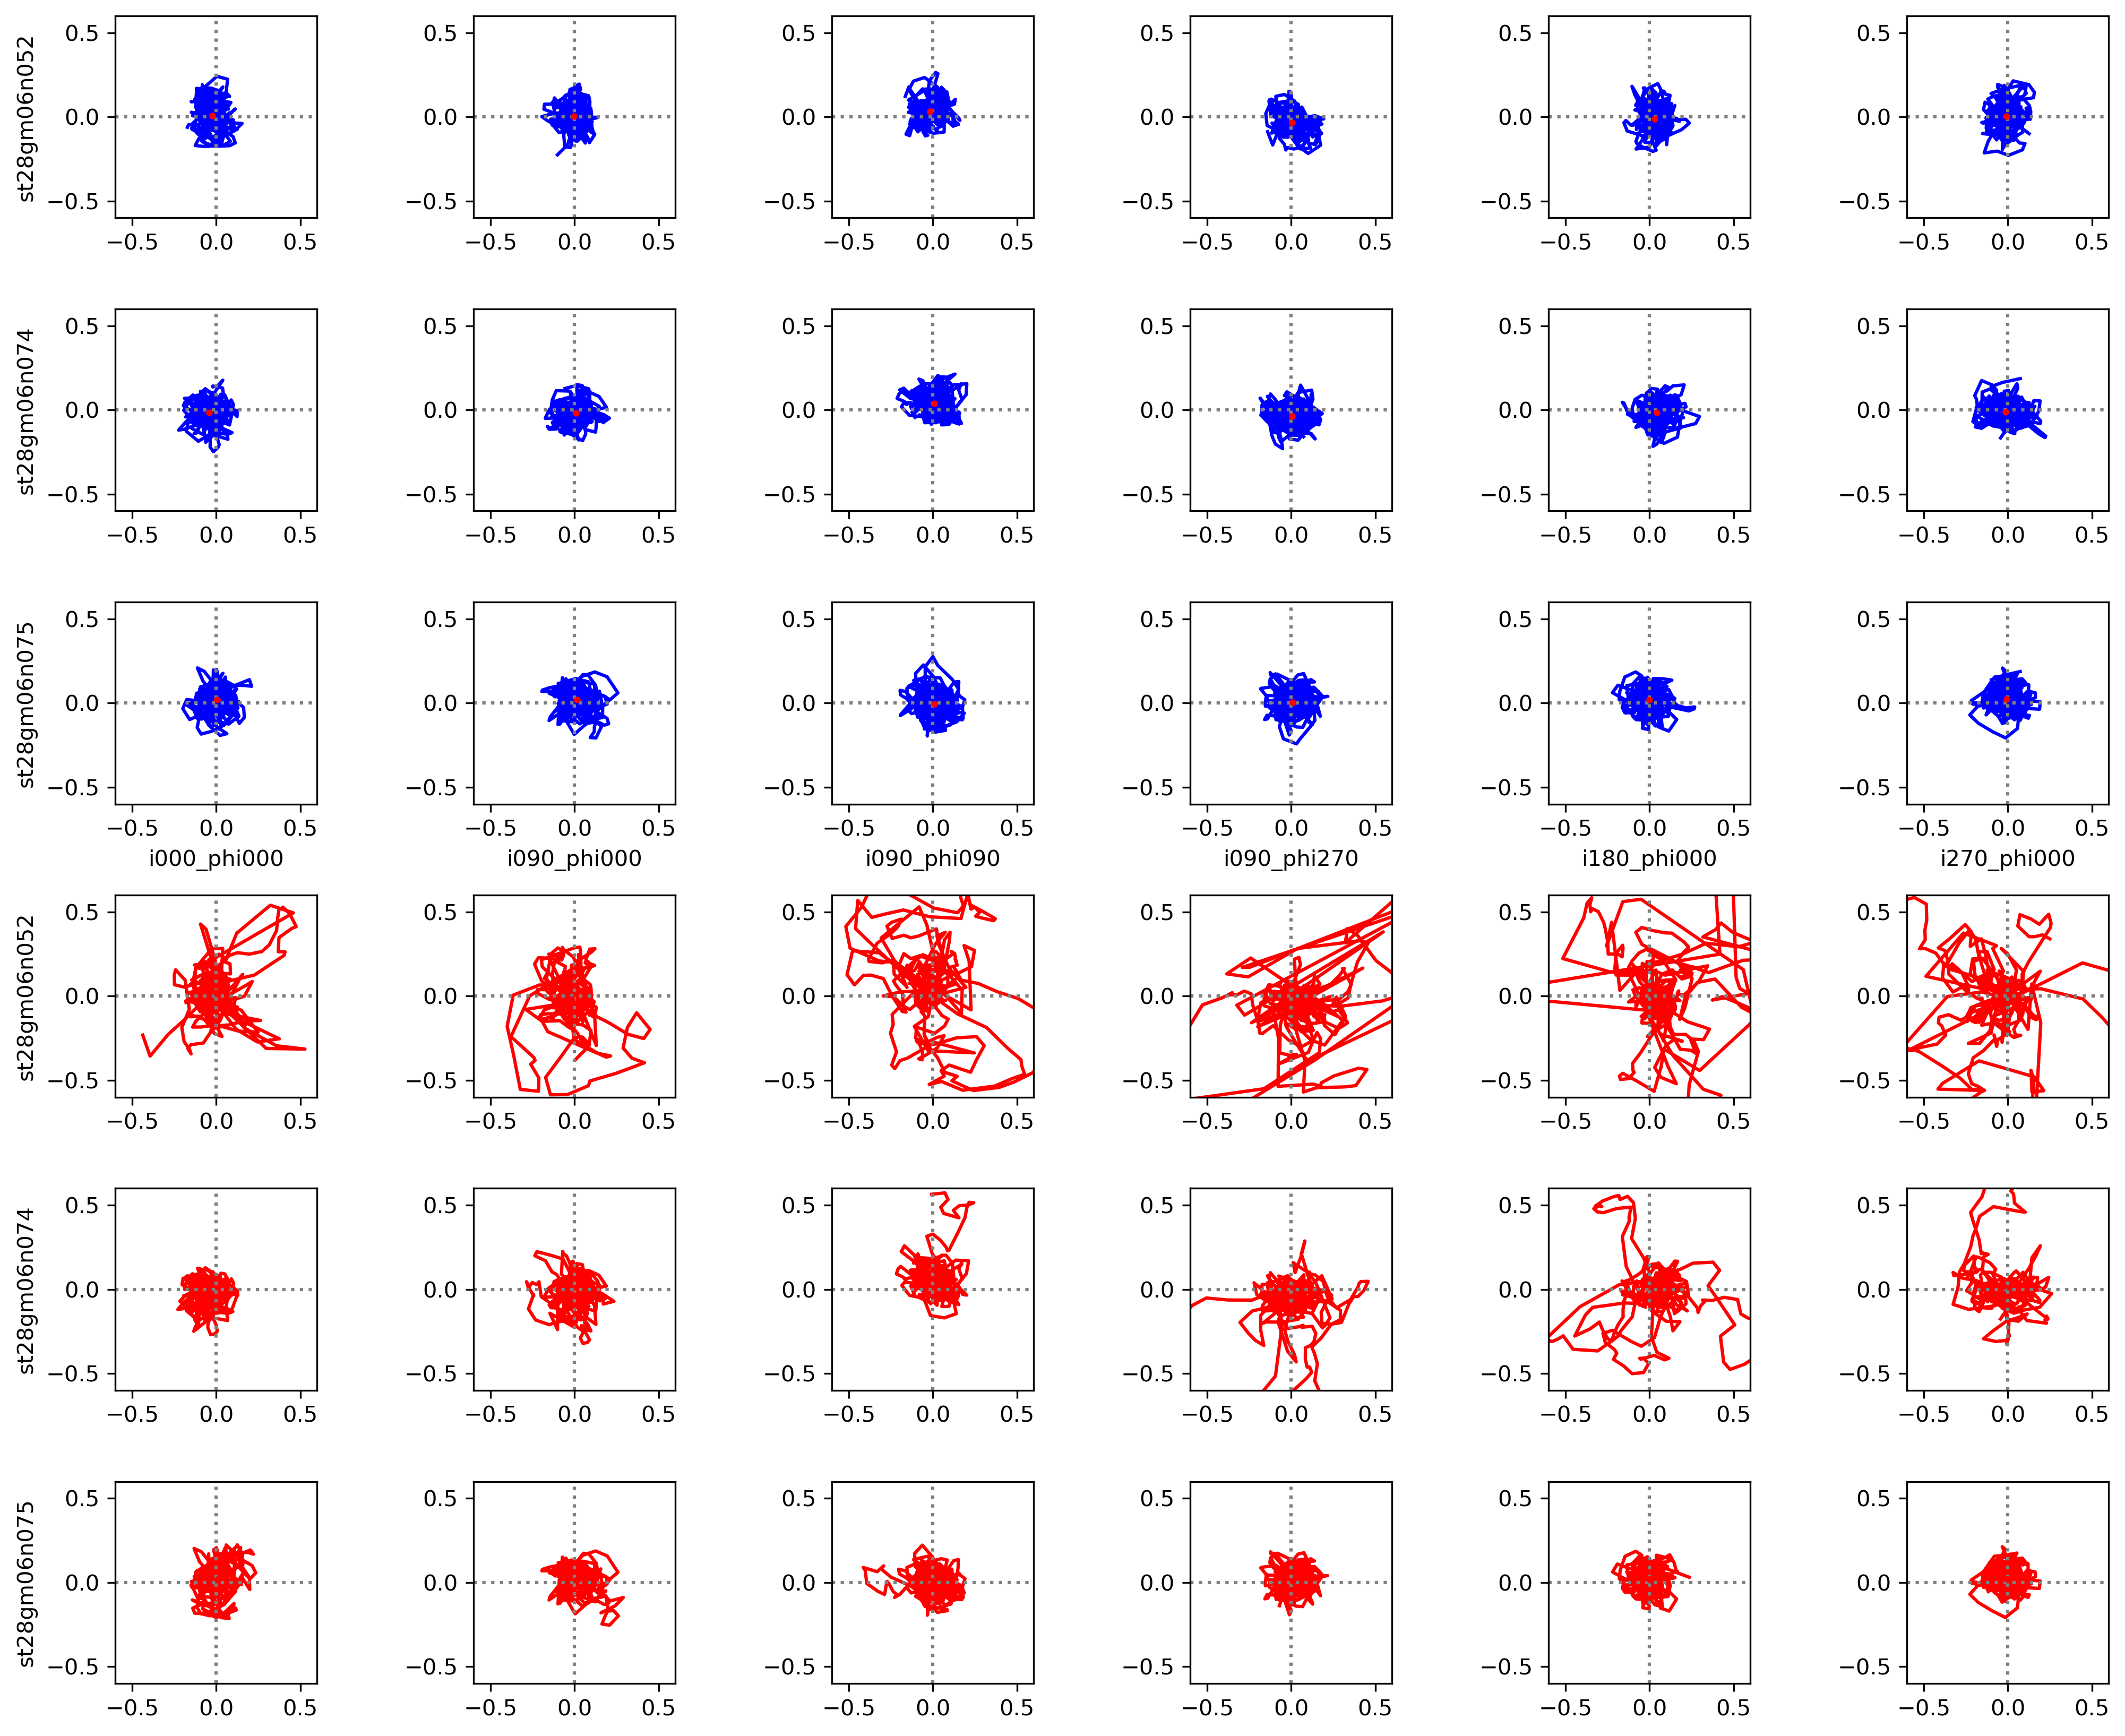

In [7]:
# Load all LOS and 3 nodust-models' photocentre coords
# and plot pcR(time) and statistics of these
# First for each model
# and then all combined, should be the same
import numpy as np
import analyze_r3d_functions as a3d
import matplotlib.pyplot as plt

wavelength = '02'
modelnames = [
    'st28gm06n052_nodust',
    'st28gm06n074_nodust',
    'st28gm06n075_nodust',
    'st28gm06n052_nospikes',
    'st28gm06n074_nospikes',
    'st28gm06n075_nospikes',
]
Nmodels = len(modelnames)
Rstar = 1.65
relaxsnaps = [
    0,0,0,0,29,29
]

angles,snapshots,coordinatelist = a3d.load_photocentre_file(
    file_path=f'../r3dresults/{modelnames[0]}/photocentre_02um.dat'
)
Nangles = len(angles)
Nsnapshots = len(snapshots)

# Initiate figure
fig,ax = plt.subplots(
    Nmodels,Nangles,
    dpi=300,
    figsize = (14,11)
)
boxsize = 0.6

for nmodel,modelname in enumerate(modelnames):
    # Set relaxation snapshotnumber
    relaxsnap = relaxsnaps[nmodel]
    # set plot colour, blue for star, red for star+dust
    if modelname.split('_')[-1] == 'nodust':
        plotcolour = 'b'
    else:
        plotcolour = 'r'
    #
    # Load photocentre data
    angles,snapshots,coordinatelist = a3d.load_photocentre_file(
        file_path=f'../r3dresults/{modelname}/photocentre_{wavelength}um.dat'
    )
    print(f'{modelname}   #   average X , Y  (R)   # unit = Rstar')
    # Extract all R(t) for all angles and save in a list
    for nangle,angle in enumerate(angles):
 
        pcX = coordinatelist[nangle][relaxsnap:,0]/Rstar
        pcY = coordinatelist[nangle][relaxsnap:,1]/Rstar
        pcR = coordinatelist[nangle][relaxsnap:,2]/Rstar

        pcX_average = np.mean(pcX)
        pcY_average = np.mean(pcY)
        pcR_average = np.mean(pcR)

        # Print average coordinates for all angles
        print(f'  {angle}: {pcX_average:.5f} , {pcY_average:.5f}  ({pcR_average:.5f})')
        
        # Plot x-y for all
        ax[nmodel,nangle].plot(
            pcX,
            pcY,
            plotcolour
        )
        # Add some labels and plot settings
        ax[nmodel,nangle].set_xlim([-boxsize,boxsize])
        ax[nmodel,nangle].set_ylim([-boxsize,boxsize])
        if nangle == 0:
            ax[nmodel,nangle].set_ylabel(
                modelname.split('_')[0]
            )
        if nmodel == 2:
            ax[nmodel,nangle].set_xlabel(
                angle
            )
        ax[nmodel,nangle].set(
            aspect='equal'
        )
        # Add lines to show central axis
        ax[nmodel,nangle].plot(
            [0,0],[-boxsize,boxsize],
            ':',color='grey'
        )
        ax[nmodel,nangle].plot(
            [-boxsize,boxsize],[0,0],
            ':',color='grey'
        )
        # Plot average coordinates as well
        ax[nmodel,nangle].plot(
            pcX_average,pcY_average,'r.',markersize=4
        )
    # Print empty line
    print()
# Save resulting images
fig.tight_layout()
fig.savefig(f'../r3dplots/photocentre/all_{wavelength}um_photocentre_XYcoords_angles.pdf')




st28gm06n052_nodust : 0.08994684595959597 pm 0.045763663021830873 , Nsnaps: 400
st28gm06n052_nospikes : 0.22849858333333334 pm 0.2248637429487968 , Nsnaps: 400
st28gm06n074_nodust : 0.09001958300343099 pm 0.0471809821612134 , Nsnaps: 421
st28gm06n074_nospikes : 0.14701074881834977 pm 0.1501886411825966 , Nsnaps: 421
st28gm06n075_nodust : 0.08979039548022599 pm 0.04427085943540381 , Nsnaps: 413
st28gm06n075_nospikes : 0.09533229143737619 pm 0.0520595589862324 , Nsnaps: 413


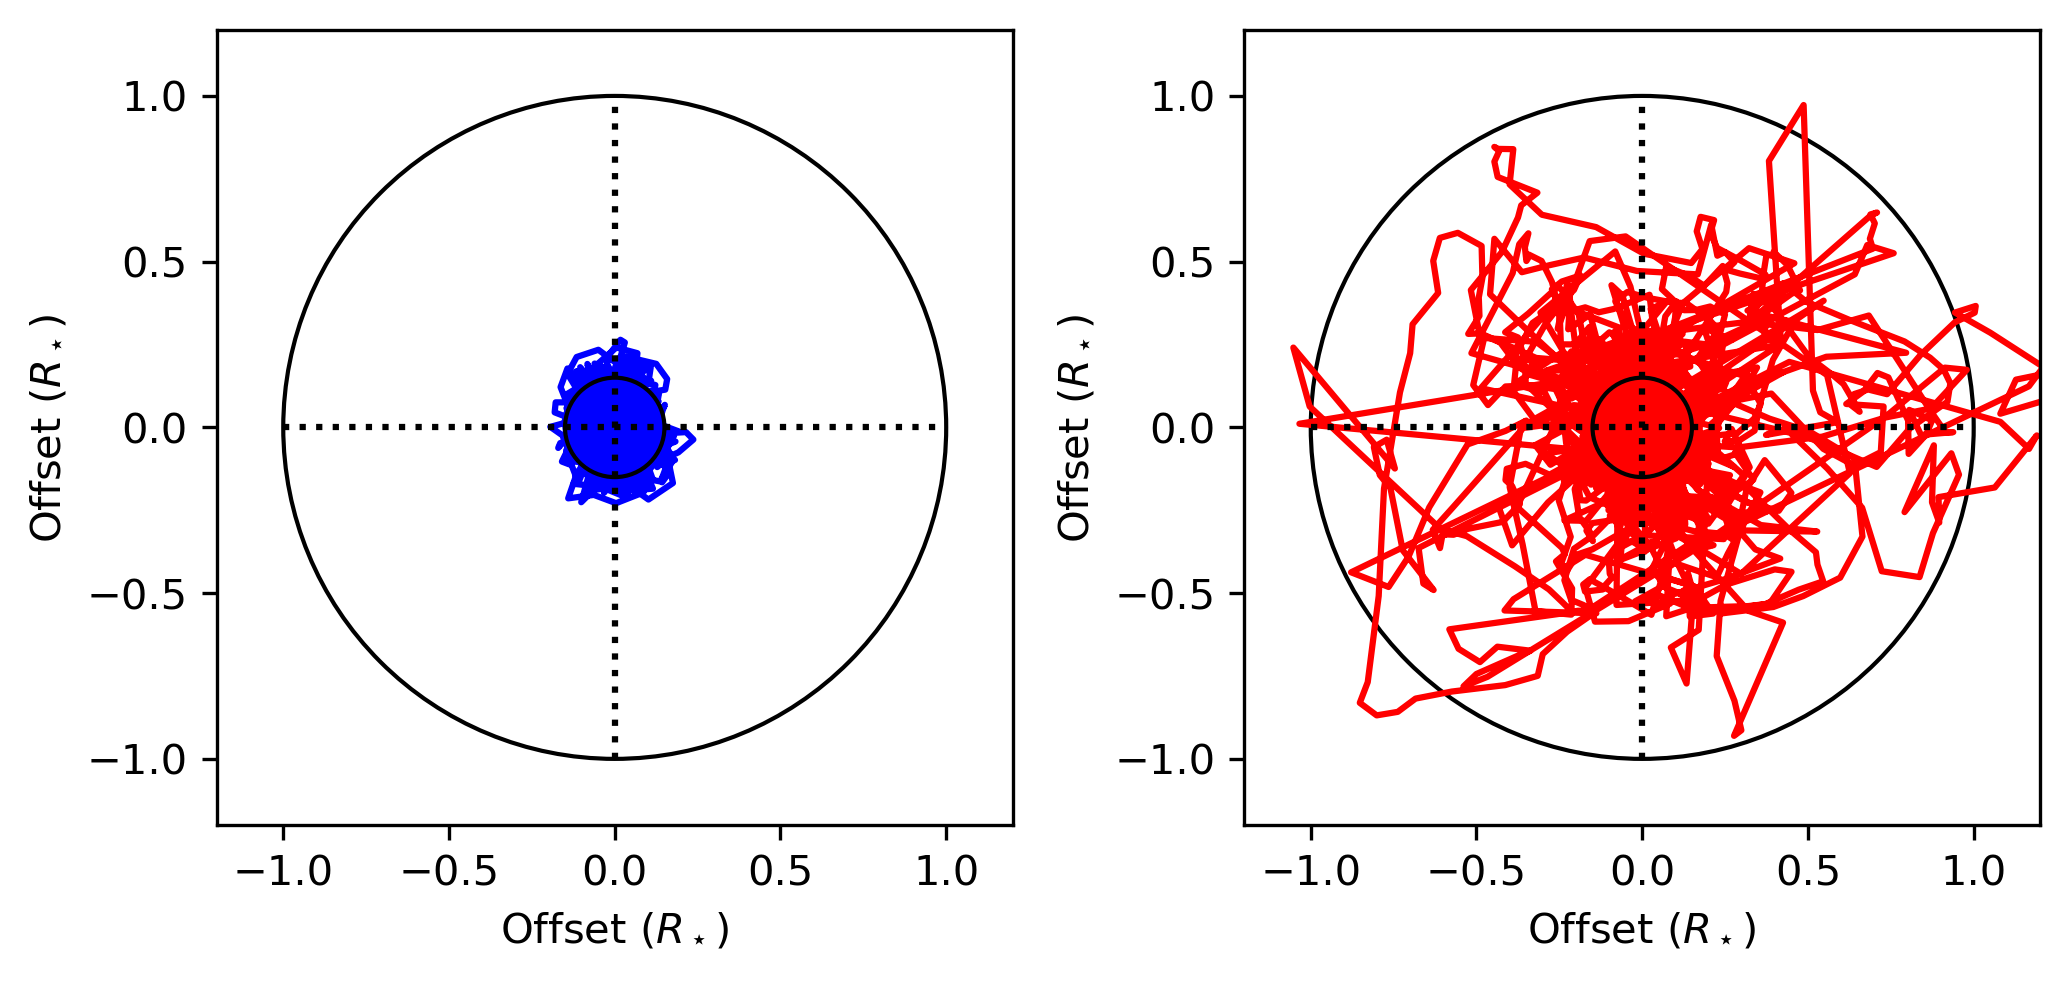

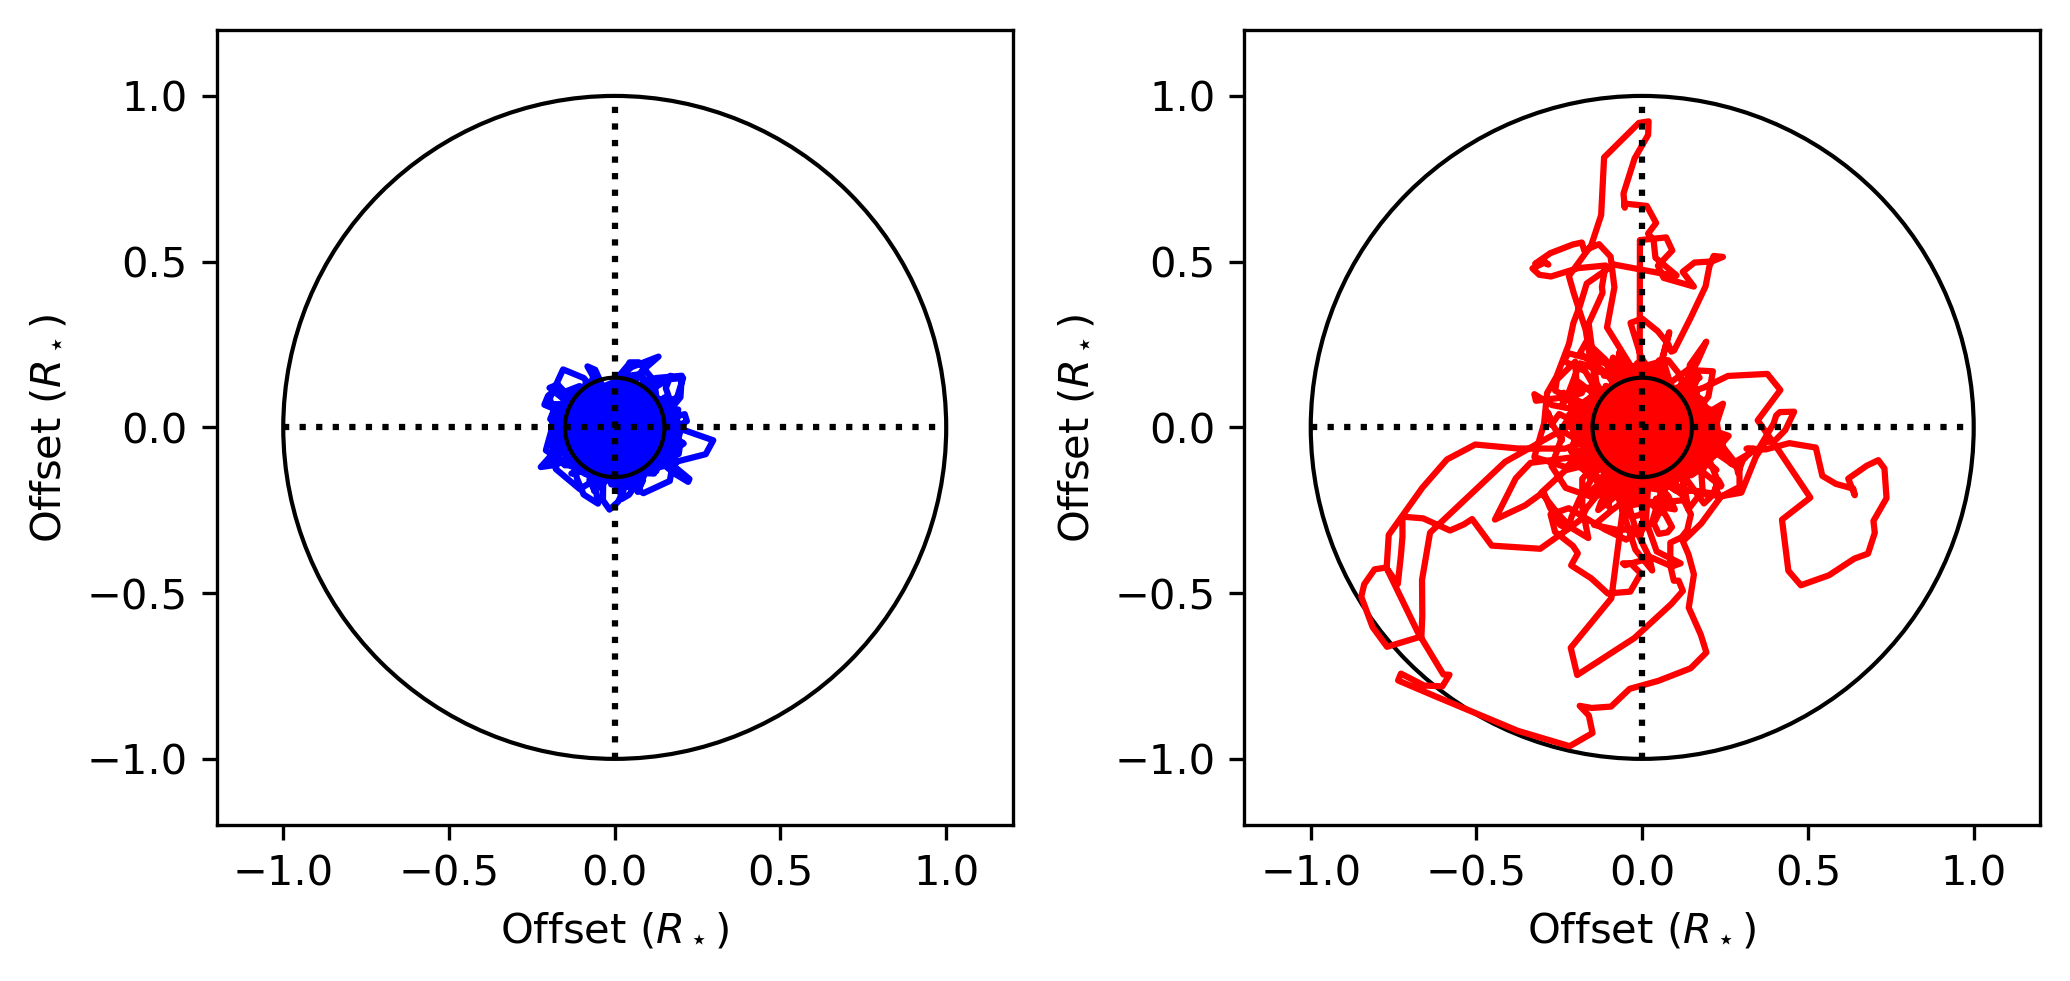

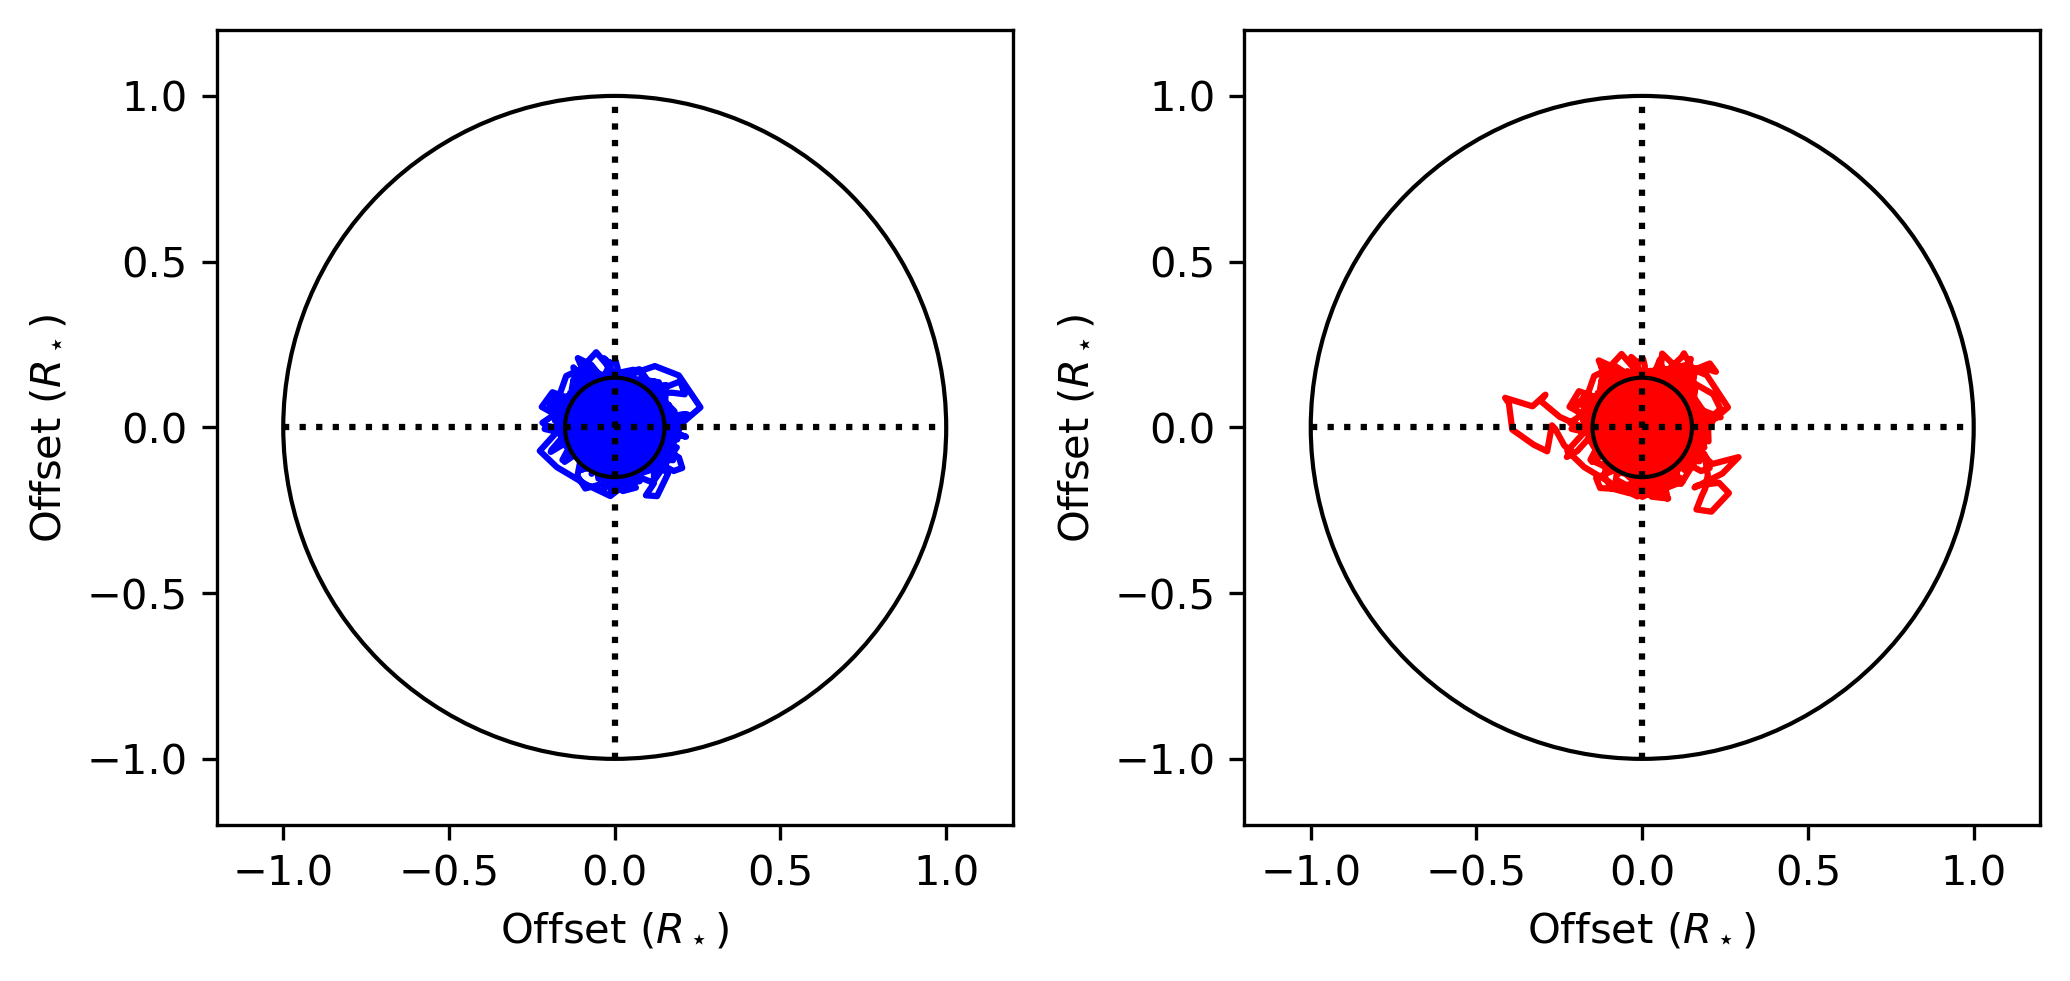

In [6]:
# Image for RS-2025R-proposal
# Left nodust of 074
# Right 074 with dust
# In terms of stellar radius
import matplotlib.pyplot as plt
import numpy as np
import analyze_r3d_functions as a3d

# Set some settings
Rstar = 1.65
wavelength = '02'
pccolour = [
    'b','r'
]
modelslist = [
    [
        'st28gm06n052_nodust',
        'st28gm06n052_nospikes'
    ],[
        'st28gm06n074_nodust',
        'st28gm06n074_nospikes'
    ],[
        'st28gm06n075_nodust',
        'st28gm06n075_nospikes'
    ],
]
modelabbreviations = [
    '052','074','075'
]
relaxsnaps = [
    0,29,29
]
# Loop through models
for models,modelabbreviation,relaxsnap in zip(modelslist,modelabbreviations,relaxsnaps):
    # Initiate figure
    fig,ax = plt.subplots(
        1,2,
        dpi=300,
        figsize = (7,3.5)
    )
    # Loop through with and without dust
    for nmodel,model in enumerate(models):
        # Extract PC-coords
        angles,snapshots,coordinatelist = a3d.load_photocentre_file(
            file_path=f'../r3dresults/{model}/photocentre_{wavelength}um.dat'
        )
        Nangles = len(angles)
        Nsnapshots = len(snapshots) - relaxsnap

        # Put all PCcoords in one array regardless of observed angle
        # With X,Y,R
        all_coords = np.zeros((Nangles*Nsnapshots,3))

        # Loop through angles and fill that array
        for nangle in range(Nangles):
            all_coords[nangle*Nsnapshots:(nangle+1)*Nsnapshots,0] = coordinatelist[nangle][relaxsnap:,0]/Rstar
            all_coords[nangle*Nsnapshots:(nangle+1)*Nsnapshots,1] = coordinatelist[nangle][relaxsnap:,1]/Rstar
            all_coords[nangle*Nsnapshots:(nangle+1)*Nsnapshots,2] = coordinatelist[nangle][relaxsnap:,2]/Rstar

        # Plot all photocentre coords
        ax[nmodel].plot(
            all_coords[:,0],all_coords[:,1],color=pccolour[nmodel]
        )
        # Plot circle for stars size and 15% av star
        ax[nmodel].add_patch(plt.Circle(
            (0,0),1,color='k',fill=False
        ))
        ax[nmodel].add_patch(plt.Circle(
            (0,0),0.15,color='k',fill=False,zorder=10
        ))
        # Plot middle lines
        ax[nmodel].plot(
            [-1,1],[0,0],'k:'
        )
        ax[nmodel].plot(
            [0,0],[-1,1],'k:'
        )
        ax[nmodel].set(
            xlim=(-1.2,1.2),
            ylim=(-1.2,1.2),
            xlabel=r'Offset ($R_\star$)',
            ylabel=r'Offset ($R_\star$)',
            aspect='equal'
        )
        # Extract statistics for each model, average and std for each
        # to write in the proposal
        print(f'{model} : {np.average(all_coords[:,2])} pm {np.std(all_coords[:,2])} , Nsnaps: {Nsnapshots}')
    fig.tight_layout()
    fig.savefig(f'../r3dplots/photocentre/{modelabbreviation}_{wavelength}um_photocentre_allcoords.pdf',dpi=300)


st28gm06n052_nodust
  i000_phi000 X: -0.02156 +- 0.05939
          Y: 0.00800 +- 0.08280
          R: 0.09376 +- 0.04604
  i090_phi000 X: -0.00464 +- 0.06127
          Y: 0.00237 +- 0.07099
          R: 0.08472 +- 0.04054
  i090_phi090 X: -0.01575 +- 0.06593
          Y: 0.03291 +- 0.06376
          R: 0.08762 +- 0.04546
  i090_phi270 X: 0.00670 +- 0.07133
          Y: -0.03356 +- 0.06309
          R: 0.08783 +- 0.05025
  i180_phi000 X: 0.03212 +- 0.05971
          Y: -0.01066 +- 0.07847
          R: 0.09419 +- 0.04469
  i270_phi000 X: -0.00654 +- 0.06310
          Y: 0.00330 +- 0.08057
          R: 0.09157 +- 0.04627

st28gm06n074_nodust
  i000_phi000 X: -0.04070 +- 0.06493
          Y: -0.01423 +- 0.06447
          R: 0.08919 +- 0.04771
  i090_phi000 X: 0.00874 +- 0.06812
          Y: -0.01724 +- 0.05895
          R: 0.08127 +- 0.04341
  i090_phi090 X: 0.01011 +- 0.07327
          Y: 0.03927 +- 0.05907
          R: 0.09050 +- 0.04808
  i090_phi270 X: 0.00545 +- 0.07569
          Y: -

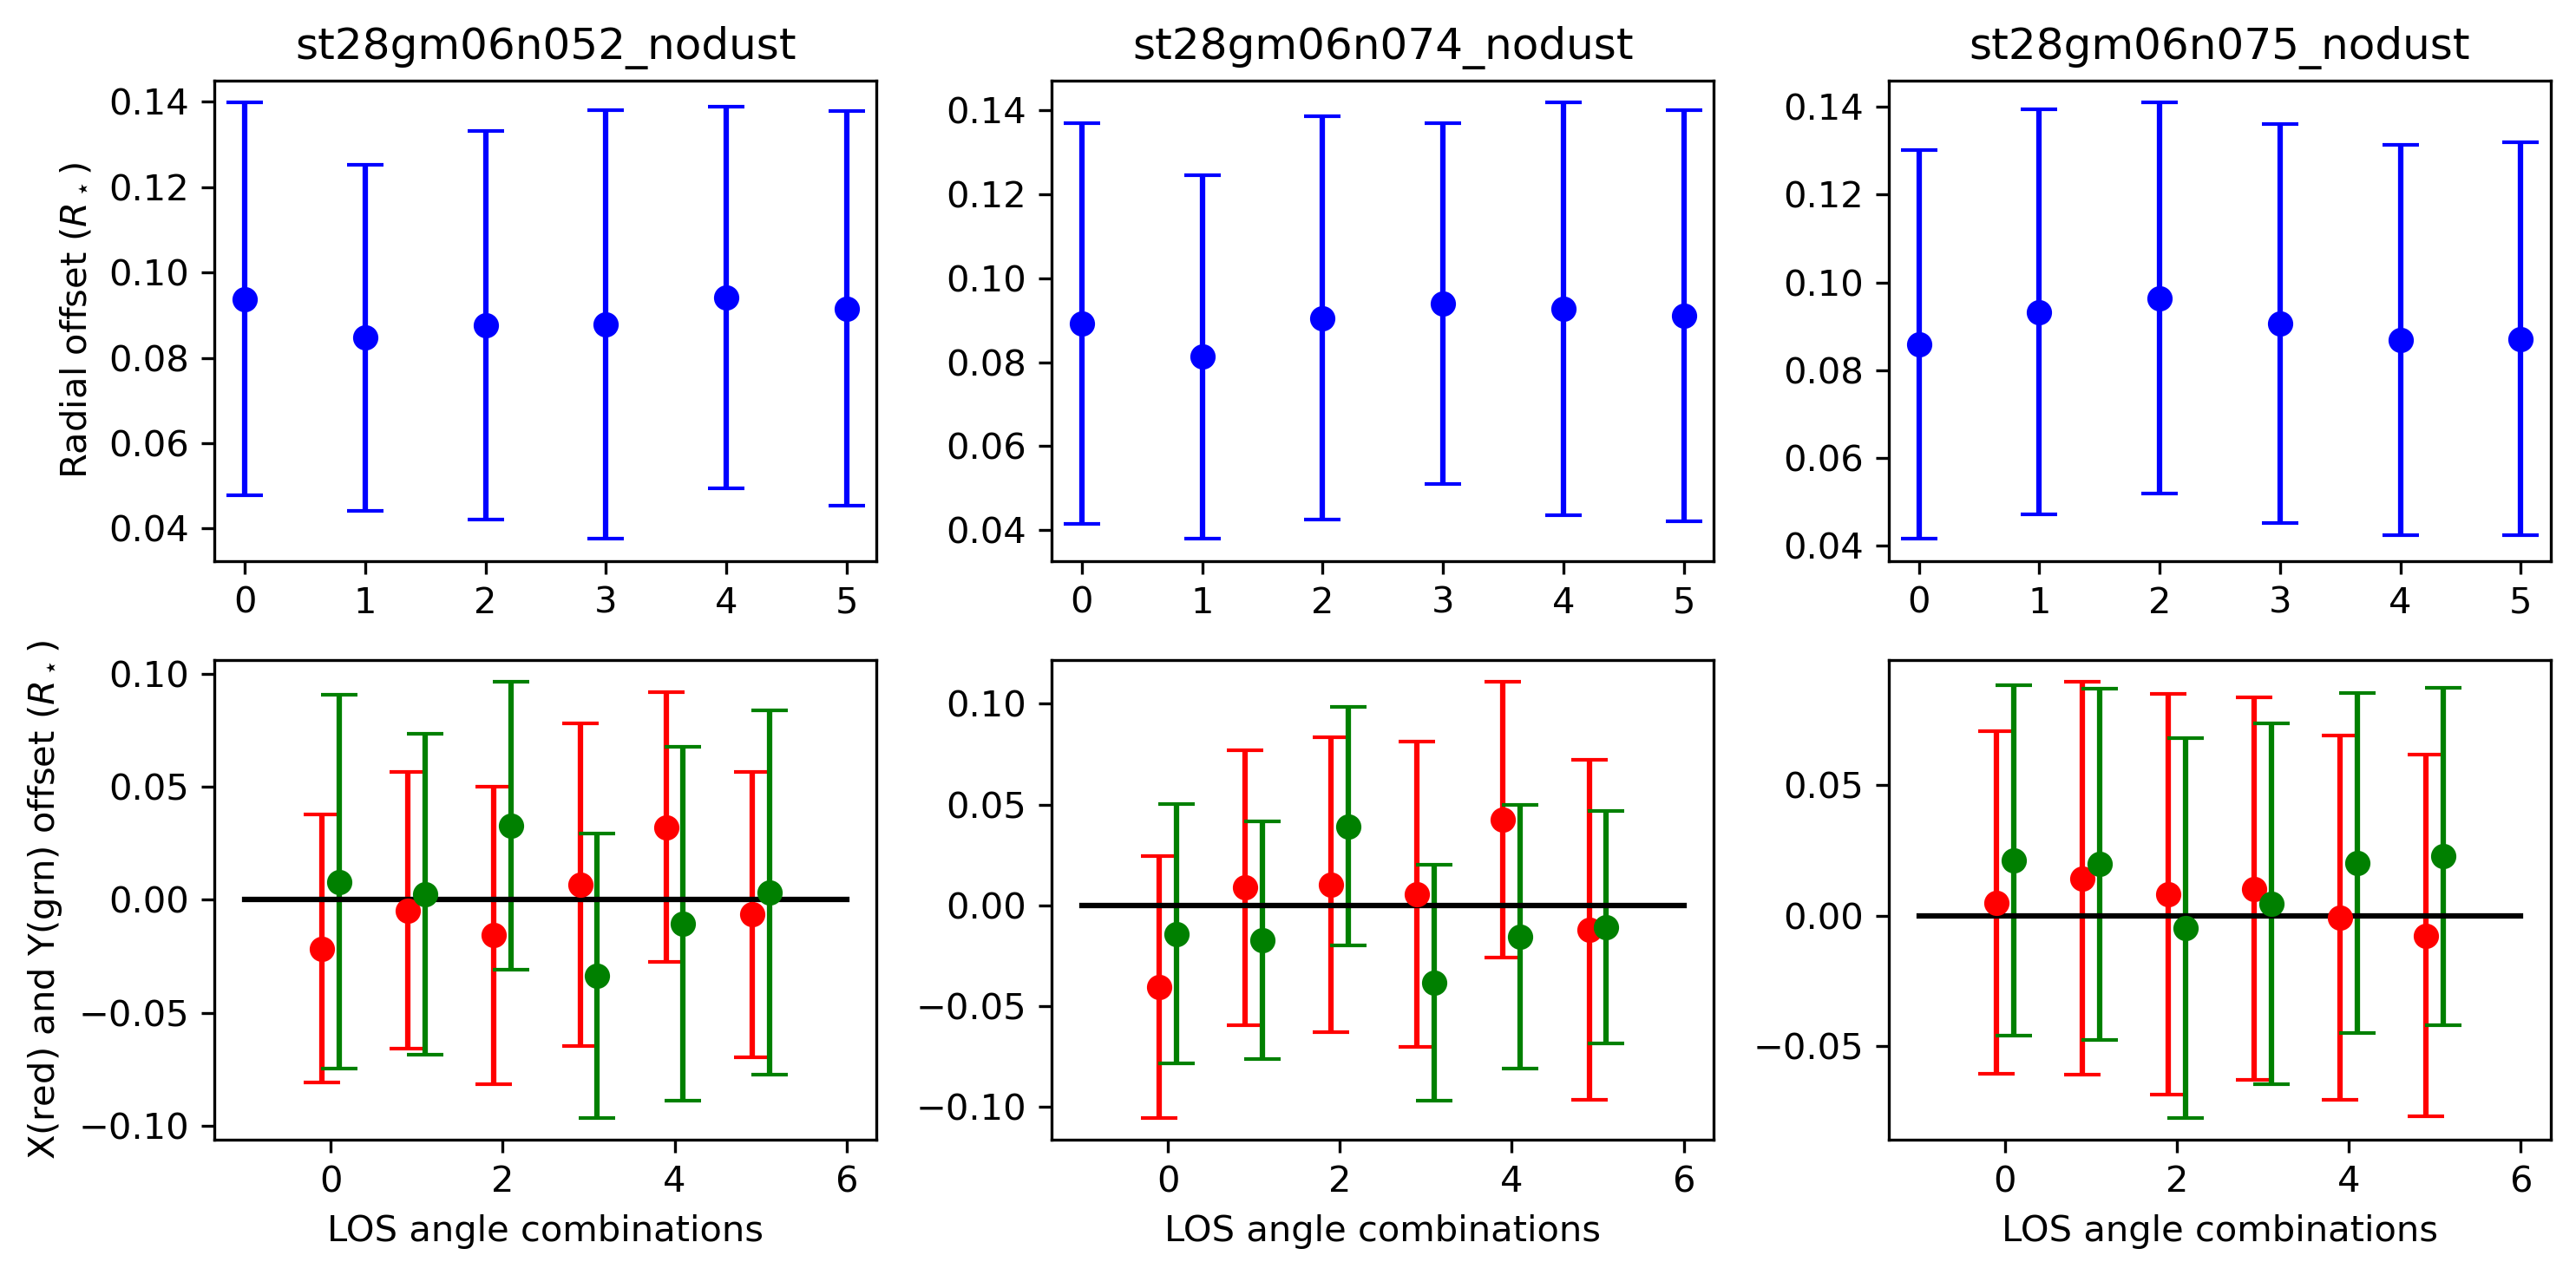

In [13]:
# Print average XY-coords for each LOS,  plusminus std
# Plot average XY and R vs LOS
#
# For the star only
import numpy as np
import analyze_r3d_functions as a3d
import matplotlib.pyplot as plt


modelnames = [
    'st28gm06n052_nodust',
    'st28gm06n074_nodust',
    'st28gm06n075_nodust',
]
Nmodels = len(modelnames)
Rstar = 1.65
wavelength = '02'
# Initiate figure
fig,ax = plt.subplots(
    2,Nmodels,
    dpi=300,
    figsize = (10,5)
)
for nmodel,modelname in enumerate(modelnames):
    # Load 
    angles,snapshots,coordinatelist = a3d.load_photocentre_file(
        file_path=f'../r3dresults/{modelname}/photocentre_{wavelength}um.dat'
    )
    Nangles = len(angles)
    Nsnapshots = len(snapshots)
    print(modelname)
    # Extract all pc(t) for all angles and save in a list
    for nangle,angle in enumerate(angles):
 
        pcX = coordinatelist[nangle][:,0]/Rstar
        pcY = coordinatelist[nangle][:,1]/Rstar
        pcR = coordinatelist[nangle][:,2]/Rstar

        pcX_average = np.mean(pcX)
        pcY_average = np.mean(pcY)
        pcR_average = np.mean(pcR)

        pcX_std = np.std(pcX)
        pcY_std = np.std(pcY)
        pcR_std = np.std(pcR)


        # Print average coordinates for all angles
        print(f'  {angle} X: {pcX_average:.5f} +- {pcX_std:.5f}')
        print(f'          Y: {pcY_average:.5f} +- {pcY_std:.5f}')
        print(f'          R: {pcR_average:.5f} +- {pcR_std:.5f}')

        # Plot LOS-variations of R
        ax[0,nmodel].errorbar(
            nangle,pcR_average,yerr=pcR_std,
            color='b',fmt='o',capsize=5
        )
        # Plot LOS-variations of X&Y
        ax[1,nmodel].errorbar(
            nangle-0.1,pcX_average,yerr=pcX_std,
            color='r',fmt='o',capsize=5
        )
        ax[1,nmodel].errorbar(
            nangle+0.1,pcY_average,yerr=pcY_std,
            color='g',fmt='o',capsize=5
        )
    # And a zero-line
    ax[1,nmodel].plot(
        [-1,6],[0,0],'k'
    )
    # Add labels
    ax[1,nmodel].set_xlabel('LOS angle combinations')
    ax[0,nmodel].set_title(modelname)
    # Print empty line
    print()
# Add labels
ax[0,0].set_ylabel(r'Radial offset ($R_\star$)')
ax[1,0].set_ylabel(r'X(red) and Y(grn) offset ($R_\star$)')
# save figure
fig.tight_layout()
fig.savefig(f'../r3dplots/photocentre/all_nodust_{wavelength}um_los-dependent.pdf')


st28gm06n052_nospikes
  i000_phi000 X: -0.00062 +- 0.12463
          Y: 0.01904 +- 0.14362
          R: 0.14314 +- 0.12662
  i090_phi000 X: -0.01844 +- 0.10911
          Y: -0.01808 +- 0.15151
          R: 0.14722 +- 0.11770
  i090_phi090 X: -0.02213 +- 0.18316
          Y: 0.07293 +- 0.26023
          R: 0.25387 +- 0.20644
  i090_phi270 X: 0.08798 +- 0.29748
          Y: -0.04964 +- 0.20707
          R: 0.25431 +- 0.27731
  i180_phi000 X: 0.11721 +- 0.25037
          Y: 0.01124 +- 0.22791
          R: 0.26891 +- 0.23702
  i270_phi000 X: -0.08690 +- 0.31102
          Y: -0.03899 +- 0.24831
          R: 0.30354 +- 0.27446

st28gm06n074_nospikes
  i000_phi000 X: -0.04919 +- 0.06753
          Y: -0.02439 +- 0.07143
          R: 0.09826 +- 0.05498
  i090_phi000 X: -0.00400 +- 0.08655
          Y: -0.03757 +- 0.08916
          R: 0.11140 +- 0.06676
  i090_phi090 X: 0.01234 +- 0.07983
          Y: 0.06145 +- 0.10854
          R: 0.11487 +- 0.09428
  i090_phi270 X: -0.01140 +- 0.16527
       

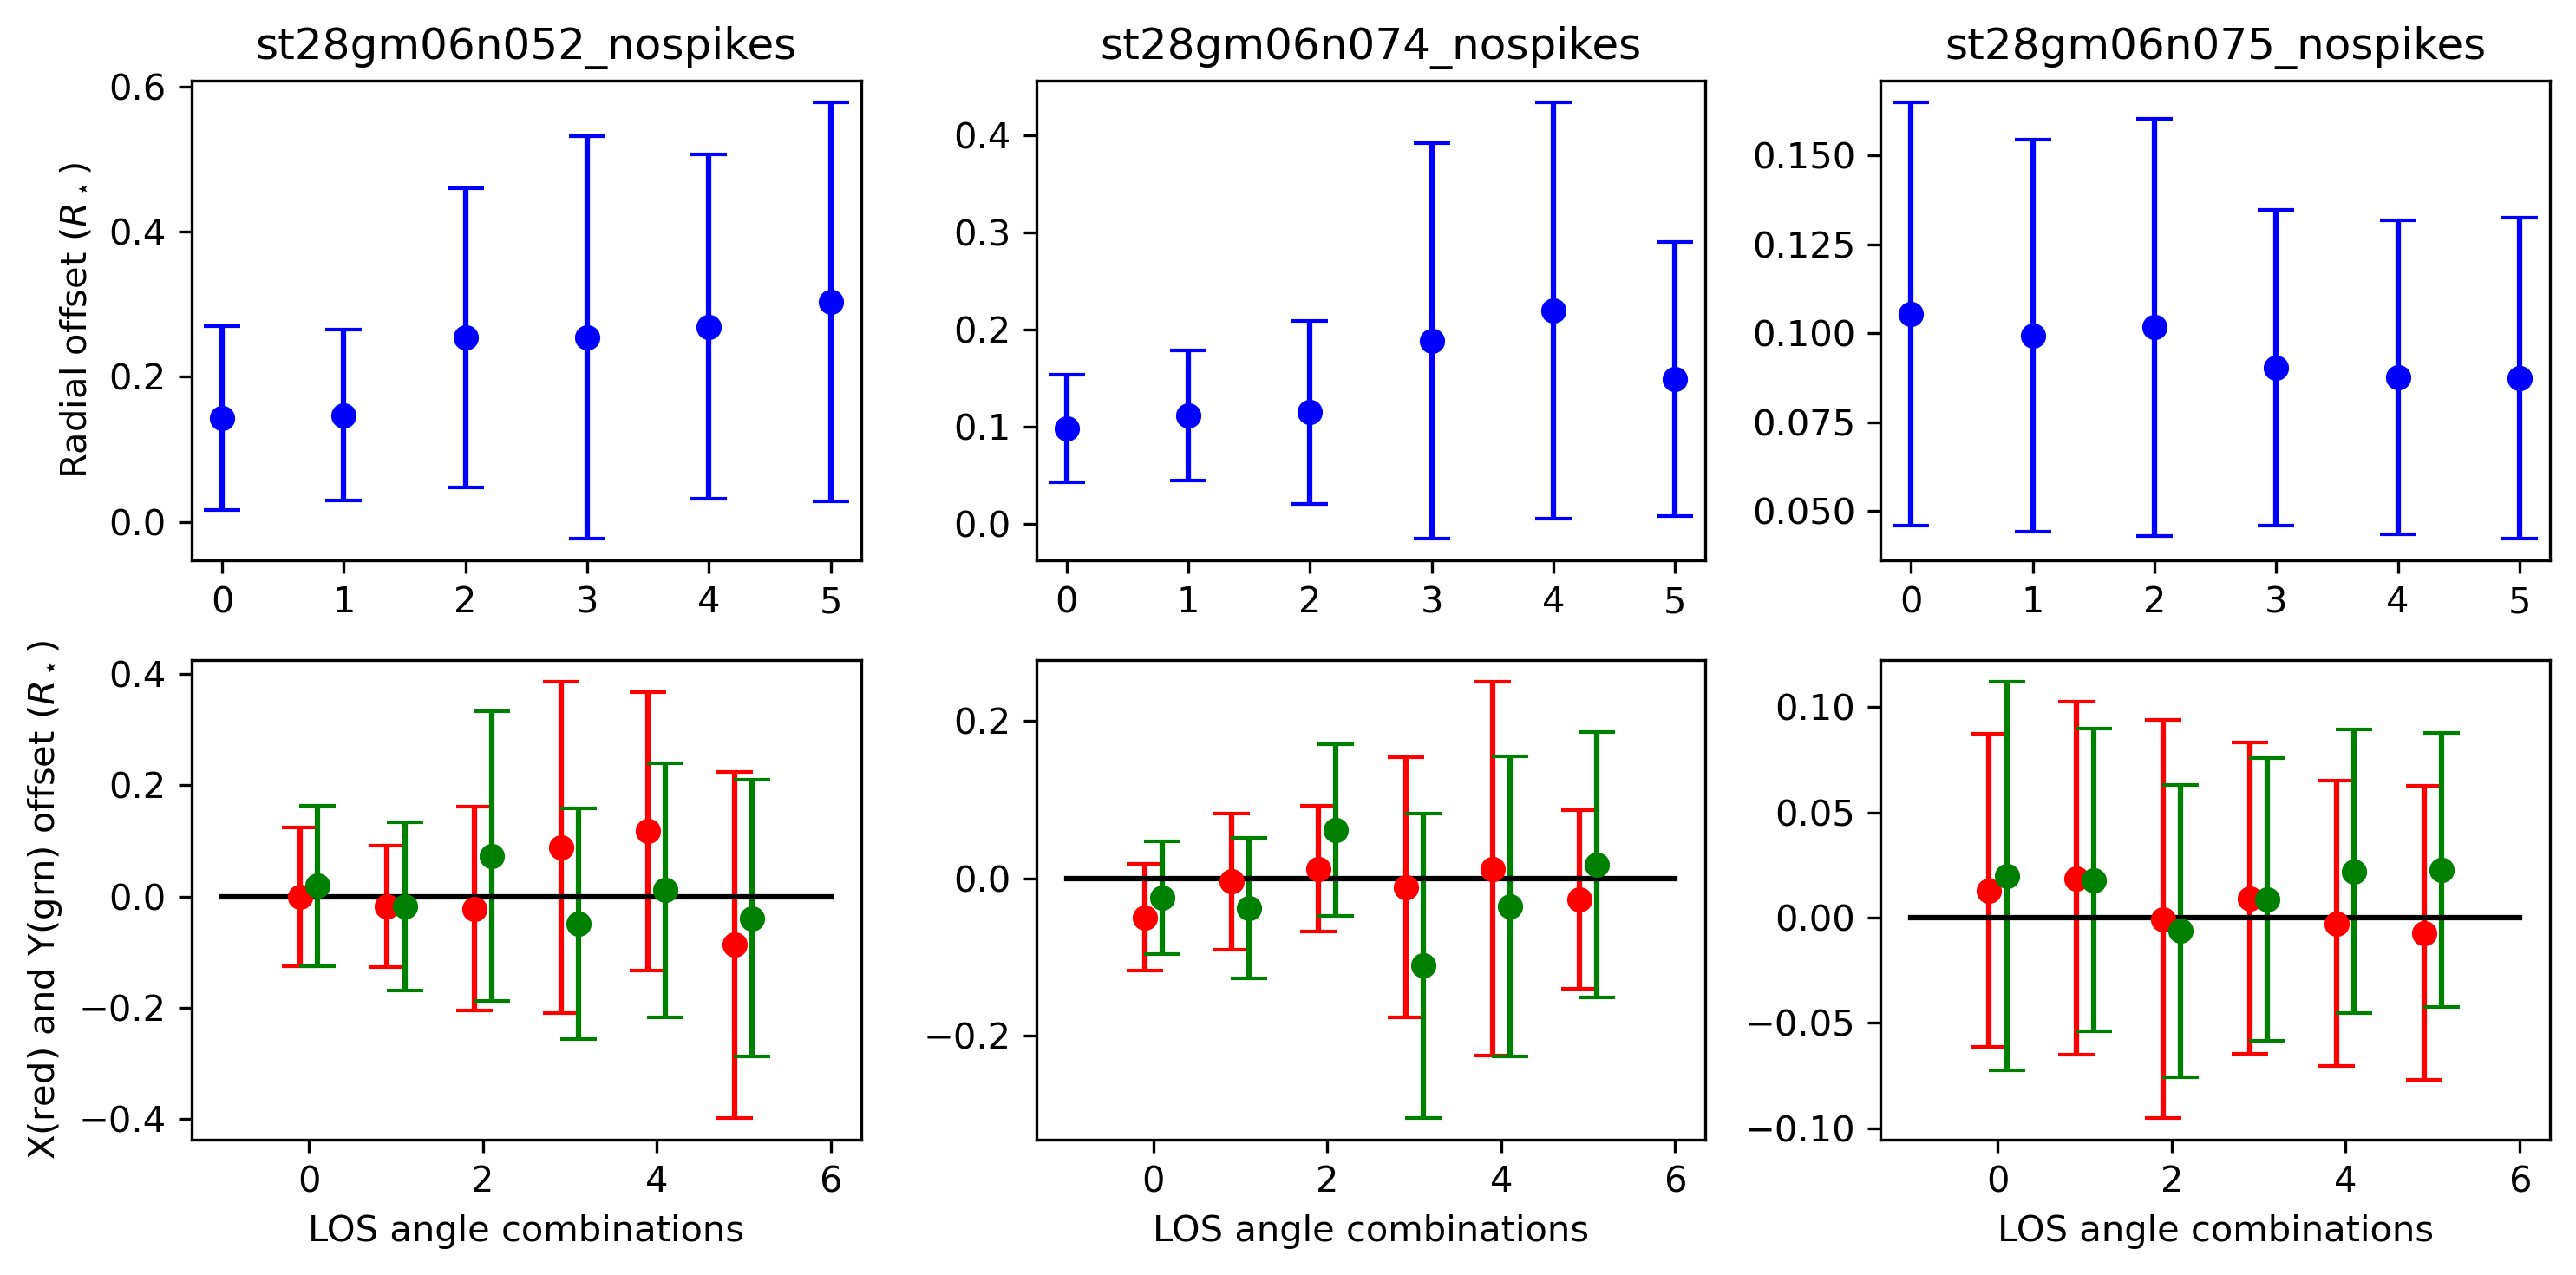

In [14]:
# Print average XY-coords for each LOS,  plusminus std
# Plot average XY and R vs LOS
#
# Star plus dust
import numpy as np
import analyze_r3d_functions as a3d
import matplotlib.pyplot as plt

modelnames = [
    'st28gm06n052_nospikes',
    'st28gm06n074_nospikes',
    'st28gm06n075_nospikes',
]
Nmodels = len(modelnames)
Rstar = 1.65
wavelength = '02'
relaxsnaps = [
    0,29,29
]
# Initiate figure
fig,ax = plt.subplots(
    2,Nmodels,
    dpi=300,
    figsize = (10,5)
)
boxsize = 0.3

for nmodel,modelname in enumerate(modelnames):
    # Set relaxation snapshot
    relaxsnap = relaxsnaps[nmodel]
    # Extract PC movements
    angles,snapshots,coordinatelist = a3d.load_photocentre_file(
        file_path=f'../r3dresults/{modelname}/photocentre_{wavelength}um.dat'
    )
    print(modelname)

    # Extract all pc(t) for all angles and save in a list
    for nangle,angle in enumerate(angles):
 
        pcX = coordinatelist[nangle][relaxsnap:,0]/Rstar
        pcY = coordinatelist[nangle][relaxsnap:,1]/Rstar
        pcR = coordinatelist[nangle][relaxsnap:,2]/Rstar

        pcX_average = np.mean(pcX)
        pcY_average = np.mean(pcY)
        pcR_average = np.mean(pcR)

        pcX_std = np.std(pcX)
        pcY_std = np.std(pcY)
        pcR_std = np.std(pcR)

        # Print average coordinates for all angles
        print(f'  {angle} X: {pcX_average:.5f} +- {pcX_std:.5f}')
        print(f'          Y: {pcY_average:.5f} +- {pcY_std:.5f}')
        print(f'          R: {pcR_average:.5f} +- {pcR_std:.5f}')

        # Plot LOS-variations of R
        ax[0,nmodel].errorbar(
            nangle,pcR_average,yerr=pcR_std,
            color='b',fmt='o',capsize=5
        )
        # Plot LOS-variations of X&Y
        ax[1,nmodel].errorbar(
            nangle-0.1,pcX_average,yerr=pcX_std,
            color='r',fmt='o',capsize=5
        )
        ax[1,nmodel].errorbar(
            nangle+0.1,pcY_average,yerr=pcY_std,
            color='g',fmt='o',capsize=5
        )
    # And a zero-line
    ax[1,nmodel].plot(
        [-1,6],[0,0],'k'
    )
    # Add labels
    ax[1,nmodel].set_xlabel('LOS angle combinations')
    ax[0,nmodel].set_title(modelname)
    # Print empty line
    print()
# Add labels
ax[0,0].set_ylabel(r'Radial offset ($R_\star$)')
ax[1,0].set_ylabel(r'X(red) and Y(grn) offset ($R_\star$)')
# save figure
fig.tight_layout()
fig.savefig(f'../r3dplots/photocentre/all_stardust_{wavelength}um_los-dependent.pdf')


## Tests on GAIA data

In [2]:
# Load and test to extract photocentre on observed AGB stars
